# Courtship song — paper-ready figures

Per paired courtship bout this notebook answers four questions:

1. Which fly is the male? (the singer — Drosophila courtship song is male-produced)
2. What song types is he performing? (pulse / sine / waggle / quiet)
3. What are his walking patterns during singing? (forward speed, turn rate, walking vs stopped)
4. How does his center-of-mass height change across song types?

Data source: the post-rescue relinked h5 produced by `rescue_identity_relink_inplace.py`.
All reusable logic lives in `utils/song_analysis.py`, `utils/sex_id.py`, `utils/locomotion.py`.
The sandbox notebook `Courtship_Song_Analysis.ipynb` is untouched; this is a clean sibling.


In [1]:
# --- Setup: imports + matplotlib style + output dir ---
from __future__ import annotations

import os, sys, pickle, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Project imports (notebook runs from the repo root OR from notebooks/)
REPO_ROOT = Path('.').resolve()
if not (REPO_ROOT / 'utils').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.courtship_loader import (
    load_courtship_h5, pair_bouts, get_fields, analyze_pair, analyze_all_pairs,
)
from utils.pair_validity import PairValidityConfig
from utils.song_analysis import SongAnalysisConfig
from utils.sex_id import SexIdConfig
from utils.locomotion import LocomotionConfig
from utils.locomotion import walking_fraction

# Paper-ready matplotlib defaults: Type-1 / sans-serif / clean spines
mpl.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.transparent': False,
})
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# Colors shared across figures
SONG_COLORS = {
    'pulse':  '#d62728',  # red
    'sine':   '#1f77b4',  # blue
    'waggle': '#9467bd',  # purple
    'quiet':  '#bdbdbd',  # grey
}
# After the reorder in analyze_pair, slot 0 = male, slot 1 = female.
FLY_COLORS = {'fly0': '#ff7f0e', 'fly1': '#2ca02c'}  # male, female

FIG_DIR = REPO_ROOT / 'figures' / 'courtship'
FIG_DIR.mkdir(parents=True, exist_ok=True)

H5_PATH = Path('/data2/users/eabe/datasets/Johnson_lab/courtship/04092026_bouts_04112026/'
               'v1/'
               'ik_output_combined_v1_courtship_both.h5')

CACHE_PATH = FIG_DIR / 'per_bout_cache.pkl'

print(f'repo   : {REPO_ROOT}')
print(f'h5     : {H5_PATH}')
print(f'figures: {FIG_DIR}')


repo   : /home/eabe/Research/MyRepos/3d_tracking_dataset
h5     : /data2/users/eabe/datasets/Johnson_lab/courtship/04092026_bouts_04112026/v1/ik_output_combined_v1_courtship_both.h5
figures: /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship


In [2]:
from utils.courtship_loader import load_and_merge_courtship_h5
# --- Load the relinked h5 and pair fly0/fly1 bouts ---
# Each bout key in this h5 holds ONE fly's kp_data / xpos_egocentric / qpos.
# The pairing is consecutive (fly0, fly1) and validated by info['source_flies'].

print('loading h5 (slow — full file)...')
# data, info, kp_names, bout_keys = load_courtship_h5(H5_PATH)

H5_SESSION0 = Path('/data2/users/eabe/datasets/Johnson_lab/courtship/'
                   'Session0/2025_10_20_13_20_04/v1/ik_output_combined_v1_courtship_both.h5')
H5_MAIN = Path('/data2/users/eabe/datasets/Johnson_lab/courtship/'
               '04092026_bouts_04112026/v1/ik_output_combined_v1_courtship_both.h5')

data, info, kp_names, bout_keys = load_and_merge_courtship_h5([H5_SESSION0, H5_MAIN])


pairs = pair_bouts(bout_keys, info)
print(f'bouts: {len(bout_keys)}  pairs: {len(pairs)}  kp: {len(kp_names)}')
print(f'first 3 pairs: {pairs[:3]}')


loading h5 (slow — full file)...
bouts: 310  pairs: 155  kp: 50
first 3 pairs: [('bout_000', 'bout_001'), ('bout_002', 'bout_003'), ('bout_004', 'bout_005')]


In [3]:
# --- Run the full per-pair analysis and cache to a pickle ---
# Set FORCE=True to invalidate the cache and re-run from scratch.
FORCE = True

song_cfg = SongAnalysisConfig()
sex_cfg  = SexIdConfig()
loc_cfg  = LocomotionConfig()
pair_cfg = PairValidityConfig()

results = analyze_all_pairs(
    data, pairs, kp_names,
    cache_path=CACHE_PATH,
    force=FORCE,
    song_cfg=song_cfg,
    sex_cfg=sex_cfg,
    loc_cfg=loc_cfg,
    pair_cfg=pair_cfg,
)

print(f'ok: {len(results)} pair results loaded')


  processed 25/155
  processed 50/155
  processed 75/155
  processed 100/155
  processed 125/155
  processed 150/155
  filtered out 35/155 non-singing pairs (min_T=100, min_dz_p95=12.0):
    pair   0 (bout_000/bout_001): dz_p95=8.73 < 12.00
    pair   3 (bout_006/bout_007): T=81 < 100
    pair   4 (bout_008/bout_009): dz_p95=6.51 < 12.00
    pair   5 (bout_010/bout_011): dz_p95=4.30 < 12.00
    pair   6 (bout_012/bout_013): dz_p95=5.27 < 12.00
    pair   8 (bout_016/bout_017): dz_p95=2.49 < 12.00
    pair   9 (bout_018/bout_019): dz_p95=6.45 < 12.00
    pair  11 (bout_022/bout_023): T=34 < 100
    pair  12 (bout_024/bout_025): dz_p95=11.73 < 12.00
    pair  18 (bout_036/bout_037): dz_p95=2.13 < 12.00
    pair  21 (bout_042/bout_043): dz_p95=7.69 < 12.00
    pair  23 (bout_046/bout_047): T=51 < 100
    pair  32 (bout_064/bout_065): T=95 < 100
    pair  33 (bout_066/bout_067): T=95 < 100
    pair  39 (bout_078/bout_079): T=51 < 100
    pair  50 (bout_100/bout_101): dz_p95=2.24 < 12.00
  

In [4]:
# --- Build a per-bout results dataframe for figures + CSV export ---
def _frac(labels, valid):
    labels = np.asarray(labels); valid = np.asarray(valid, dtype=bool)
    n = int(valid.sum())
    if n == 0:
        return {k: float('nan') for k in ('pulse', 'sine', 'waggle', 'quiet')}
    sel = labels[valid]
    return {k: float(np.mean(sel == k)) for k in ('pulse', 'sine', 'waggle', 'quiet')}

rows = []
for r in results:
    sex = r['sex']
    fr  = _frac(r['male_labels'], r['male_valid'])
    bs  = r['by_song']
    row = {
        'pair_idx':                   r['pair_idx'],
        # Post-swap keys: key0 is always the male's original bout, key1 the female's.
        'key0':                       r['key0'],
        'key1':                       r['key1'],
        'T':                          r['T'],
        'male_id':                    sex['male_id'],
        'female_id':                  sex['female_id'],
        'criterion':                  sex['criterion'],
        'confidence':                 sex['confidence'],
        'disagree_bodylen':           sex['disagree'],
        # Semantic (post-swap) song fractions. slot0=male, slot1=female.
        'song_fraction_male':         r['song0']['summary']['song_fraction'],
        'song_fraction_female':       r['song1']['summary']['song_fraction'],
        'body_length_male':           sex['body_length_male'],
        'body_length_female':         sex['body_length_female'],
        # Raw tracker-slot record for traceability + Figure 1.
        'tracker_male_id':            r['tracker_male_id'],
        'tracker_key0':               r['tracker_key0'],
        'tracker_key1':               r['tracker_key1'],
        'tracker_song_fraction_fly0': r['tracker_song_fraction_fly0'],
        'tracker_song_fraction_fly1': r['tracker_song_fraction_fly1'],
        'frac_pulse':                 fr['pulse'],
        'frac_sine':                  fr['sine'],
        'frac_waggle':                fr['waggle'],
        'frac_quiet':                 fr['quiet'],
        'walking_fraction':           walking_fraction(r['walking_state'][r['male_valid']]) if r['male_valid'].any() else float('nan'),
        'mean_com_z':                 float(np.nanmean(r['com_z'][r['male_valid']])) if r['male_valid'].any() else float('nan'),
        'mean_speed_bl':              float(np.nanmean(r['kin'].get('speed_bl', r['kin']['speed'])[r['male_valid']])) if r['male_valid'].any() else float('nan'),
    }
    # Song-conditioned aggregates
    for song in ('pulse', 'sine', 'waggle', 'quiet'):
        stats = bs.get(song, {})
        for m in ('speed_bl', 'forward_speed_bl', 'turn_rate', 'com_z'):
            row[f'{song}_{m}_mean'] = stats.get(m, {}).get('mean', float('nan'))
            row[f'{song}_{m}_n']    = stats.get(m, {}).get('n',    0)
    rows.append(row)

df = pd.DataFrame(rows)
print(df.shape)
df.head(25)


(120, 57)


,pair_idx,key0,key1,T,male_id,female_id,criterion,confidence,disagree_bodylen,song_fraction_male,song_fraction_female,body_length_male,body_length_female,tracker_male_id,tracker_key0,tracker_key1,tracker_song_fraction_fly0,tracker_song_fraction_fly1,frac_pulse,frac_sine,frac_waggle,frac_quiet,walking_fraction,mean_com_z,mean_speed_bl,pulse_speed_bl_mean,pulse_speed_bl_n,pulse_forward_speed_bl_mean,pulse_forward_speed_bl_n,pulse_turn_rate_mean,pulse_turn_rate_n,pulse_com_z_mean,pulse_com_z_n,sine_speed_bl_mean,sine_speed_bl_n,sine_forward_speed_bl_mean,sine_forward_speed_bl_n,sine_turn_rate_mean,sine_turn_rate_n,sine_com_z_mean,sine_com_z_n,waggle_speed_bl_mean,waggle_speed_bl_n,waggle_forward_speed_bl_mean,waggle_forward_speed_bl_n,waggle_turn_rate_mean,waggle_turn_rate_n,waggle_com_z_mean,waggle_com_z_n,quiet_speed_bl_mean,quiet_speed_bl_n,quiet_forward_speed_bl_mean,quiet_forward_speed_bl_n,quiet_turn_rate_mean,quiet_turn_rate_n,quiet_com_z_mean,quiet_com_z_n
0,1,bout_003,bout_002,878,fly0,fly1,body_length,0.104774,False,1.000000,1.000000,0.172946,0.176648,fly1,bout_002,bout_003,1.000000,1.000000,0.136674,0.863326,0.000000,0.000000,1.0,0.145300,3.693375,4.617301,120,1.732315,120,-145.842201,120,0.159014,120,3.547108,758,2.540541,758,15.768256,758,0.143129,758,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
1,2,bout_004,bout_005,306,fly0,fly1,body_length,0.122606,False,1.000000,1.000000,0.158157,0.162133,fly0,bout_004,bout_005,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.0,0.130581,27.567674,27.567674,306,23.432329,306,-17.009613,306,0.130581,306,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
2,7,bout_015,bout_014,1061,fly0,fly1,song_fraction,0.061836,True,1.000000,0.938164,0.173137,0.171897,fly1,bout_014,bout_015,0.938164,1.000000,0.273327,0.726673,0.000000,0.000000,1.0,0.120632,2.867728,3.511439,290,0.645715,290,-8.529107,290,0.127720,290,2.625605,771,-0.264423,771,-2.524451,771,0.117965,771,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
3,10,bout_021,bout_020,903,fly0,fly1,body_length,0.207730,False,1.000000,1.000000,0.166290,0.173498,fly1,bout_020,bout_021,1.000000,1.000000,0.565891,0.434109,0.000000,0.000000,1.0,0.128318,11.398280,14.976167,511,13.525770,511,47.234408,511,0.132811,511,6.734250,392,4.523906,392,16.905676,392,0.122461,392,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
4,13,bout_026,bout_027,203,fly0,fly1,body_length,0.008835,False,1.000000,1.000000,0.170295,0.170596,fly0,bout_026,bout_027,1.000000,1.000000,0.773399,0.226601,0.000000,0.000000,1.0,0.171167,19.000555,20.815769,157,16.174794,157,9.607600,157,0.171301,157,12.805151,46,10.133224,46,-74.943595,46,0.170712,46,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
5,14,bout_029,bout_028,266,fly0,fly1,song_fraction,0.181132,False,1.000000,0.818868,0.170270,0.181452,fly1,bout_028,bout_029,0.818868,1.000000,0.669173,0.330827,0.000000,0.000000,1.0,0.135426,5.819150,4.326154,178,2.971337,178,-17.315413,178,0.136820,178,8.839075,88,3.621034,88,55.533156,88,0.132607,88,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
6,15,bout_031,bout_030,812,fly0,fly1,body_length,0.577361,False,1.000000,0.980296,0.152980,0.172951,fly1,bout_030,bout_031,0.980296,1.000000,0.025862,0.974138,0.000000,0.000000,1.0,0.118297,3.457611,6.623687,21,-4.740942,21,-45.240653,21,0.113293,21,3.373556,791,0.605506,791,7.541645,791,0.118429,791,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
7,16,bout_033,bout_032,1292,fly0,fly1,body_length,0.173057,False,1.000000,1.000000,0.162793,0.168629,fly1,bout_032,bout_033,1.000000,1.000000,0.773994,0.226006,0.000000,0.000000,1.0,0.115101,8.076716,8.942333,1000,6.680925,1000,12.505726,1000,0.116876,1000,5.112276,292,2.254611,292,-4.877285,292,0.109023,292,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
8,17,bout_035,bout_034,446,fly0,fly1,song_fraction,0.107623,False,1.000000,0.892377,0.170709,0.188785,fly1,bout_034,bout_035,0.892377,1.000000,0.748879,0.251121,0.000000,0.000000,1.0,0.106157,4.944233,4.709830,334,2.66

In [5]:
%matplotlib inline
EXAMPLE_IDX = 13 # 73

# Optional sub-range (in frames, bout-relative) to zoom into a clip of
# the example bout. Inherited by Figure 3 below. None = full bout.
# When trimmed, plotted arrays are sliced so y-axes auto-scale to the
# in-range data only (extreme values outside the range are dropped).
START_FRAME = (150/1000) * 800  # inclusive
END_FRAME   = (1500/1000) * 800  # exclusive; None → render to end of bout

if EXAMPLE_IDX is None:
    example_idx = int((df['frac_pulse'] + df['frac_sine']).idxmax())
else:
    example_idx = int(EXAMPLE_IDX)
ex = results[example_idx]
print(f'example pair_idx={example_idx}  keys={ex["key0"]}/{ex["key1"]}  '
      f'T={ex["T"]} ({ex["T"]/song_cfg.fs:.3f}s)  male={ex["sex"]["male_id"]}')

fs = song_cfg.fs
male_song = ex['song0'] if ex['sex']['male_id'] == 'fly0' else ex['song1']

# ----- plotting helpers (local — not exported) ----------------------------
_SEG_COLORS = {
    'pulse':  '#E76F5133',
    'sine':   '#2A9D8F33',
    'waggle': '#E9C46A33',
    'quiet':  '#cccccc11',
}
_SEG_EDGE_COLORS = {
    'pulse':  '#E76F51',
    'sine':   '#2A9D8F',
    'waggle': '#E9C46A',
    'quiet':  '#999999',
}
_WING_COLORS = {
    'WingL_V12': '#7B2D8E', 'WingL_V13': '#A855F7',
    'WingR_V12': '#0369A1', 'WingR_V13': '#38BDF8',
}


def _add_segment_shading(ax, segments, fs, hatch=None, side_tag=None,
                         seen_labels=None, frame_range=None):
    if seen_labels is None:
        seen_labels = set()
    for seg in segments:
        stype = seg['type']
        if stype == 'quiet':
            continue
        # Clip to the visible frame range if provided; drop segments that
        # fall entirely outside so they don't pollute the legend.
        if frame_range is not None:
            lo, hi = frame_range
            if seg['end'] <= lo or seg['start'] >= hi:
                continue
            seg_start = max(seg['start'], lo)
            seg_end   = min(seg['end'],   hi)
        else:
            seg_start = seg['start']
            seg_end   = seg['end']
        s_ms = seg_start / fs * 1000.0
        e_ms = seg_end   / fs * 1000.0
        color = _SEG_COLORS.get(stype, '#cccccc33')
        label_key = f'{stype}_{side_tag}'
        if label_key in seen_labels:
            label = None
        else:
            label = f'{stype.capitalize()} {side_tag}' if side_tag else stype.capitalize()
            seen_labels.add(label_key)
        ax.axvspan(s_ms, e_ms, facecolor=color, zorder=0, label=label,
                   hatch=hatch, edgecolor=_SEG_EDGE_COLORS.get(stype),
                   linewidth=0)


def _add_segment_freq_annotations(ax, segments, window_features, fs,
                                  frame_range=None):
    wc = window_features.get('window_centers')
    pf = window_features.get('peak_freq')
    if wc is None or pf is None or len(wc) == 0:
        return
    wc = np.asarray(wc); pf = np.asarray(pf)
    for seg in segments:
        stype = seg['type']
        if stype == 'quiet':
            continue
        s, e = seg['start'], seg['end']
        if frame_range is not None:
            lo, hi = frame_range
            if e <= lo or s >= hi:
                continue
            s = max(s, lo); e = min(e, hi)
        in_seg = (wc >= s) & (wc <= e)
        if in_seg.sum() == 0:
            continue
        seg_freqs = pf[in_seg]
        median_f = float(np.nanmedian(seg_freqs))
        min_f = float(np.nanmin(seg_freqs))
        max_f = float(np.nanmax(seg_freqs))
        mid_ms = (s + e) / 2.0 / fs * 1000.0
        edge_color = _SEG_EDGE_COLORS.get(stype, '#999999')
        freq_str = f'{median_f:.0f}Hz' if min_f == max_f else f'{min_f:.0f}-{max_f:.0f}Hz'
        ax.annotate(
            freq_str,
            xy=(mid_ms, 0.02), xycoords=('data', 'axes fraction'),
            fontsize=7, color=edge_color, fontweight='bold',
            ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec=edge_color,
                      alpha=0.85, lw=0.7),
        )


def _shade_song(ax, result, fs, seen, frame_range=None):
    # L and R carry identical labels (bilateral pulse mask overwrites both),
    # so a single shading pass is enough — using L's segments.
    _add_segment_shading(ax, result['sides']['L']['segments'], fs=fs,
                         hatch=None, side_tag=None, seen_labels=seen,
                         frame_range=frame_range)


example pair_idx=13  keys=bout_050/bout_051  T=1787 (2.234s)  male=fly0


In [6]:
# # --- Figure 2 multi-page PDF: one page per pair ---
# # Generates fig2_song_all_pairs.pdf — same layout as the single-pair Figure 2
# # above, full bout per page, for easy scanning. Reuses the helpers defined in
# # the Figure 2 cell (_shade_song, _add_segment_freq_annotations, etc.), so
# # that cell must have been run first.
# from matplotlib.backends.backend_pdf import PdfPages

# _fs_song = song_cfg.fs


# def _build_song_figure_for_pair(result):
#     """Build the Figure-2 layout for one pair over the full bout. Returns fig."""
#     ms = result['song0'] if result['sex']['male_id'] == 'fly0' else result['song1']
#     idx = result['pair_idx']
#     fidx = result.get('filtered_idx')

#     T_ = ms['summary']['n_frames']
#     t_ms_ = np.arange(T_) / _fs_song * 1000.0

#     dom_ = ms['dominant_wing']
#     dom_side_ = ms['sides'][dom_]
#     wf_ = dom_side_['window_features']
#     s_ = dom_side_['summary']

#     mode_parts_ = []
#     for k, lab in (('frac_pulse', 'pulse'), ('frac_sine', 'sine'),
#                    ('frac_waggle', 'waggle'), ('frac_quiet', 'quiet')):
#         v = s_.get(k, 0.0)
#         if v > 0:
#             mode_parts_.append(f'{lab}={100*v:.0f}%')
#     mode_str_ = '  '.join(mode_parts_)

#     joints_ = ms.get('joints')
#     nrows_ = 3 if joints_ is not None else 2
#     fig_, axes_ = plt.subplots(
#         nrows_, 1, figsize=(10.0, 3.0 * nrows_), sharex=True,
#         gridspec_kw={'height_ratios': [1.2, 1.0] + ([1.2] if nrows_ == 3 else []),
#                      'hspace': 0.28},
#     )
#     if nrows_ == 1:
#         axes_ = [axes_]
#     _pair_label = (f'filtered_idx {fidx} (orig pair_idx {idx})'
#                    if fidx is not None else f'pair {idx}')
#     fig_.suptitle(
#         f'{_pair_label}  ({result["key0"]}/{result["key1"]})  |  '
#         f'{ms["summary"]["duration_s"]:.3f}s  |  male={result["sex"]["male_id"]}  |  '
#         f'dom_wing={dom_}  |  {mode_str_}',
#         fontsize=10, fontweight='bold', y=0.995,
#     )

#     wd_ = ms['wing_data']

#     # Panel 1: Wing tip Z
#     ax = axes_[0]
#     _shade_song(ax, ms, _fs_song, set())
#     ax.plot(t_ms_, np.asarray(wd_['WingL_V13']['z']),
#             color=_WING_COLORS['WingL_V13'], lw=1.2, alpha=0.9, label='L V13')
#     ax.plot(t_ms_, np.asarray(wd_['WingR_V13']['z']),
#             color=_WING_COLORS['WingR_V13'], lw=1.2, alpha=0.9, label='R V13')
#     _add_segment_freq_annotations(ax, dom_side_['segments'], wf_, _fs_song)
#     ax.set_ylabel('Z (world)')
#     ax.set_title('Wing tip Z (V13)')
#     ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7, ncol=1)
#     ax.grid(True, alpha=0.3)

#     # Panel 2: Wing tip Y
#     ax = axes_[1]
#     _shade_song(ax, ms, _fs_song, set())
#     ax.plot(t_ms_, np.asarray(wd_['WingL_V13']['y']),
#             color=_WING_COLORS['WingL_V13'], lw=1.2, alpha=0.9, label='L V13')
#     ax.plot(t_ms_, np.asarray(wd_['WingR_V13']['y']),
#             color=_WING_COLORS['WingR_V13'], lw=1.2, alpha=0.9, label='R V13')
#     ax.set_ylabel('Y (world)')
#     ax.set_title('Wing tip Y (V13)')
#     ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7, ncol=1)
#     ax.grid(True, alpha=0.3)

#     # Panel 3 (optional): qpos wing joint angles
#     if joints_ is not None:
#         ax = axes_[2]
#         _shade_song(ax, ms, _fs_song, set())
#         _joint_styles = [
#             ('yaw_L',   '#7B2D8E', '-',  'L yaw'),
#             ('roll_L',  '#7B2D8E', '--', 'L roll'),
#             ('pitch_L', '#7B2D8E', ':',  'L pitch'),
#             ('yaw_R',   '#0369A1', '-',  'R yaw'),
#             ('roll_R',  '#0369A1', '--', 'R roll'),
#             ('pitch_R', '#0369A1', ':',  'R pitch'),
#         ]
#         for jkey, jcolor, jls, jlabel in _joint_styles:
#             if jkey in joints_:
#                 ax.plot(t_ms_, np.degrees(np.asarray(joints_[jkey])),
#                         color=jcolor, ls=jls, lw=1.0, alpha=0.85, label=jlabel)
#         ax.set_ylabel('angle (deg)')
#         ax.set_title('Wing joint angles (qpos)')
#         ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7, ncol=2)
#         ax.grid(True, alpha=0.3)

#     axes_[-1].set_xlabel('time (ms)')

#     # Pulse event overlay
#     _pef = np.asarray(wf_.get('pulse_event_frames', np.array([], dtype=int)))
#     if _pef.size > 0:
#         _pef_ms = _pef / _fs_song * 1000.0
#         for _ax in axes_:
#             for i_, xm_ in enumerate(_pef_ms):
#                 _ax.axvline(xm_, color='#E76F51', lw=0.6, alpha=0.55,
#                             ls='--', zorder=4,
#                             label=(f'pulse events (n={len(_pef_ms)})'
#                                    if i_ == 0 and _ax is axes_[0] else None))
#         axes_[0].legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7)

#     return fig_


# _out_pdf = FIG_DIR / 'fig2_song_all_pairs.pdf'
# _n = len(results)
# print(f'writing {_n} pair figures to {_out_pdf}')
# with PdfPages(_out_pdf) as _pdf:
#     for _i, _r in enumerate(results):
#         try:
#             _fig = _build_song_figure_for_pair(_r)
#             _pdf.savefig(_fig, bbox_inches='tight')
#             plt.close(_fig)
#         except Exception as _e:
#             print(f'  pair {_r.get("pair_idx", _i)}: {type(_e).__name__}: {_e}')
#         if (_i + 1) % 25 == 0 or (_i + 1) == _n:
#             print(f'  wrote {_i + 1}/{_n}')
# print(f'saved {_out_pdf}')


# Figure 6 — Consolidated courtship figure

Combines the EXAMPLE_IDX=65 exemplar bout (rows 1–3) with population summaries
(row 4). Layout is built by `utils.courtship_figure_panels.assemble_figure` and
each panel is filled by an independent `panel_*` function so any panel can be
swapped out without touching the others.

Fill in the three placeholders below before running:
- `CAM_MP4_PATH` — path to the per-camera mp4 covering this bout
- `ROI`         — (x, y, w, h) crop in pixels
- `FREE_WALK_H5_PATH` — path to a non-courtship free-walking combined h5


(no orig_keypoints match for fly0 — keypoint overlays disabled)
center_xyz from kp_data fallback: shape (1061, 3)
center_xyz[0] -> uv [ 19.04054311 460.95631494] (expected 0..~512 if DLT/scale OK)
[csv override] fly0=(2007, 50, 3)  fly1=(2007, 50, 3)


NameError: name '_exemplar_full_bouts' is not defined

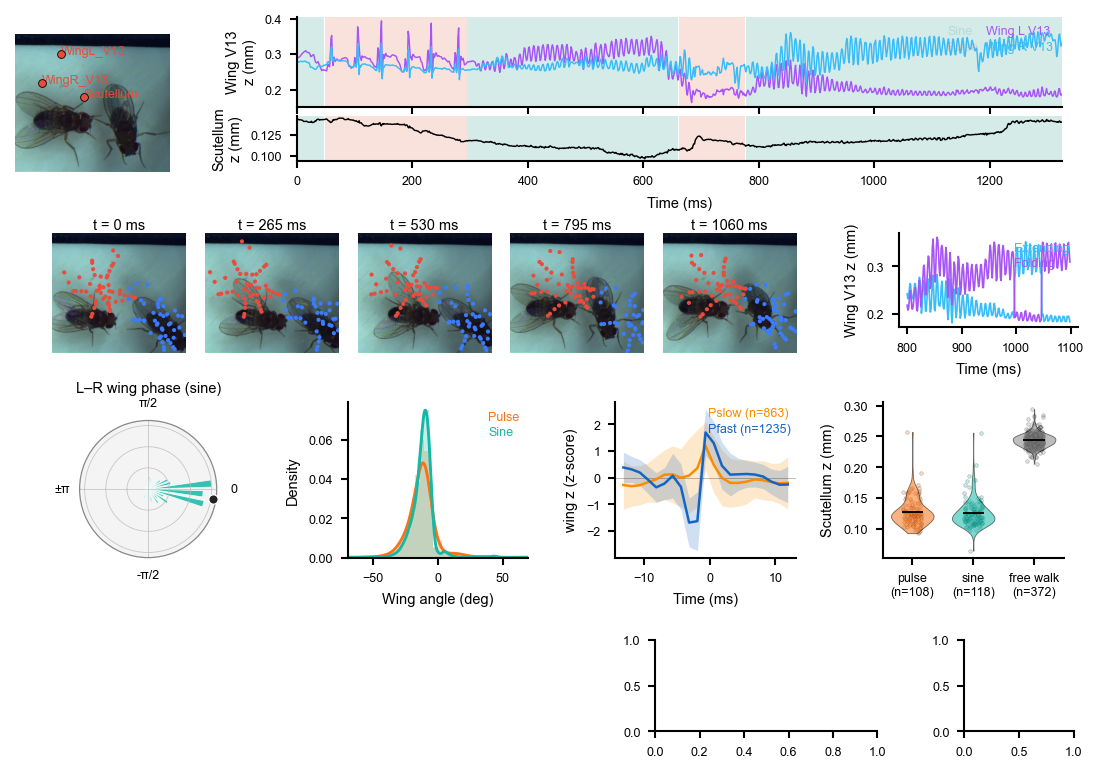

In [7]:
# --- Figure 6: Reorganized consolidated courtship figure (183 mm × 130 mm) ---
import importlib
import sys
import numpy as np
import matplotlib.pyplot as plt

from utils import courtship_figure_panels as cfp
from utils.sam3_female_com import triangulate_sam3_female_com
from utils.sam3_aligned_bouts import compute_per_bout_pitch_alignment
from utils import courtship_loader as _cl
from utils import pulse_type_cache as _ptc
from utils import free_walking_loader as _fwl

importlib.reload(cfp)
importlib.reload(_cl)
importlib.reload(_ptc)
importlib.reload(_fwl)
get_pulse_type_labels = _ptc.get_pulse_type_labels
load_free_walking_scutellum_z = _fwl.load_free_walking_scutellum_z
load_orig_keypoints_index = _cl.load_orig_keypoints_index
get_orig_keypoints_for_combined_bout = _cl.get_orig_keypoints_for_combined_bout

# ------------------------------------------------------------------ inputs
# --- Video (rows 1+2) -------------------------------------------------
CAM_MP4_PATH  = "/data2/users/eabe/datasets/Johnson_lab/courtship/Session0/2025_10_20_13_20_04/Cam2012630.mp4"
DLT_CSV_PATH  = "/data2/users/eabe/datasets/Johnson_lab/courtship/Session0/2025_10_20_13_20_04/calibration/Cam2012630_dlt.csv"
# CAM_MP4_PATH      = "/data2/users/eabe/datasets/Johnson_lab/courtship/Session0/2025_10_20_13_20_04/Cam2012630.mp4"
# DLT_CSV_PATH      = "/data2/users/eabe/datasets/Johnson_lab/courtship/Session0/2025_10_20_13_20_04/calibration/Cam2012630_dlt.csv"
VIDEO_ROI         = (1350, 0, 500, 500)             # (x, y, w, h) static crop in raw video pixels
DATA3D_FLY0_CSV   = '/data2/users/eabe/datasets/Johnson_lab/courtship/Session0/2025_10_20_13_20_04/Predictions_3D_V4_phase4_enumfix/bout_00028/fly1.csv'
DATA3D_FLY1_CSV   = '/data2/users/eabe/datasets/Johnson_lab/courtship/Session0/2025_10_20_13_20_04/Predictions_3D_V4_phase4_enumfix/bout_00028/fly0.csv'
KP_LABEL_FRAME    = None                            # None = middle of strip
KP_LABEL_OFFSETS  = {                               # text nudge in cropped px
    "Scutellum":  (0,0),#( 8, -4),
    "WingL_V13":  (0,0),#(-12, -10),
    "WingR_V13":  (0,0),#( 12, -10),
}
KP_SCALE         = 0.1                              # 3D unit -> DLT unit (mm -> cm here)
SAM3_MASK_PATH = '/data2/users/eabe/datasets/Johnson_lab/courtship/Session0/2025_10_20_13_20_04/Predictions_3D_V4_phase4_enumfix/bout_00028/sam3_masks.npz'
CALIB_DIR      = '/data2/users/eabe/datasets/Johnson_lab/courtship/Session0/2025_10_20_13_20_04/calibration'
SAM3_ALIGNED_H5 = '/data2/users/eabe/datasets/Johnson_lab/courtship/Session0/2025_10_20_13_20_04/Predictions_3D_34662304/sam3_aligned.h5'
BOUTS_ROOT      = '/data2/users/eabe/datasets/Johnson_lab/courtship/Session0/2025_10_20_13_20_04/Predictions_3D_34662304'
EXEMPLAR_H5_FLY0 = '/data2/users/eabe/datasets/Johnson_lab/courtship/Session0/2025_10_20_13_20_04/Predictions_3D_V4_phase4_enumfix/v1/ik_output_combined_v1_courtship_fly0.h5'
EXEMPLAR_H5_FLY1 = '/data2/users/eabe/datasets/Johnson_lab/courtship/Session0/2025_10_20_13_20_04/Predictions_3D_V4_phase4_enumfix/v1/ik_output_combined_v1_courtship_fly1.h5'

# Original (pre-rescale) keypoints — required for correct DLT projection.
# Combined h5 stores the body-model-rescaled kp_data; orig_keypoints live
# in each per-prediction `preprocessing/preprocessed_bout_*_both.h5`.
ORIG_KP_SEARCH_DIR = "/data2/users/eabe/datasets/Johnson_lab/courtship/04092026_bouts_04112026"

# --- Free-walking dataset (row 3 right) --------------------------------
FREE_WALK_H5_PATH = "/data2/users/eabe/datasets/Johnson_lab/free_walking/Data_analysis/analysis/v1/ik_output_combined_v1_free_walking.h5"

# --- Render (row 4): male + female + floor -----------------------------
VIZ_MODEL_XML    = "/home/eabe/Research/MyRepos/fruitfly_body_models/fruitfly_v1/fruitfly_v1_free.xml"
VIZ_FLOOR_XML    = "/home/eabe/Research/MyRepos/fruitfly_body_models/fruitfly_v1/floor.xml"
VIZ_SETTINGS_FLY0 = "Earthy_V1_courtship_fly0"
VIZ_SETTINGS_FLY1 = "Earthy_V1_courtship_fly1"
VIZ_CAMERA       = "track1_fly0"
VIZ_HEIGHT       = 512
VIZ_WIDTH        = 512
RENDER_CROP_WH   = (320, 320)                      # (w, h) centered post-render crop; wider so fly1 stays in frame
RENDER_CAM_DISTANCE   = 1.75                        # midpoint-camera distance (meters)
RENDER_CAM_AZIMUTH    = 85.0                        # midpoint-camera azimuth (deg)
RENDER_CAM_ELEVATION  = -20.0                       # midpoint-camera elevation (deg)
RENDER_CROP      = (VIZ_WIDTH // 2 - RENDER_CROP_WH[0] // 2,
                    VIZ_HEIGHT // 2 - RENDER_CROP_WH[1] // 2,
                    RENDER_CROP_WH[0], RENDER_CROP_WH[1])

# --- Exemplar bout + frame selection -----------------------------------
EXAMPLE_IDX     = 2  # bout from 2026_04_02_12_11_50 (matches CAM_MP4_PATH); previously 132
START_FRAME     = int((0   / 1000) * 800)
END_FRAME       = None # int((800 / 1000) * 800)           # None => full clip
N_FRAMES_STRIP  = 6
N_RENDER_STRIP  = 4
FRAME_INDICES   = None                              # None = evenly spaced

# ------------------------------------------------------------------ slice
fs = song_cfg.fs
ex = results[EXAMPLE_IDX]

# Splice in the full-length (2006-frame) exemplar bout from the per-fly
# h5 files, then re-run analyze_pair so every panel downstream uses it.
import h5py as _h5py
def _load_single_bout_h5(path, bout_key='bout_000'):
    with _h5py.File(path, 'r') as _f:
        _b = _f[bout_key]
        return {k: _b[k][...] for k in _b.keys()
                if isinstance(_b[k], _h5py.Dataset)}
# try:
#     _bout0_full = _load_single_bout_h5(EXEMPLAR_H5_FLY0)
#     _bout1_full = _load_single_bout_h5(EXEMPLAR_H5_FLY1)
#     _fresh = analyze_pair(
#         ex['key0'], ex['key1'], _bout0_full, _bout1_full, kp_names,
#     )
#     _fresh['pair_idx'] = ex.get('pair_idx', EXAMPLE_IDX)
#     ex = _fresh
#     results[EXAMPLE_IDX] = _fresh
#     # Map key0 -> male-data, key1 -> female-data using the tracker male id so
#     # the downstream render (which concatenates qpos0||qpos1) draws slot-0 red
#     # as the male (matches analyze_pair's post-swap convention).
#     if _fresh.get('tracker_male_id') == 'fly0':
#         _male_bout, _female_bout = _bout0_full, _bout1_full
#     else:
#         _male_bout, _female_bout = _bout1_full, _bout0_full
#     _exemplar_full_bouts = {
#         _fresh['key0']: _male_bout,
#         _fresh['key1']: _female_bout,
#     }
#     print(f"[exemplar splice] tracker_male_id={_fresh.get('tracker_male_id')}"
#           f"  ->  T={int(ex['T'])}")
# except (FileNotFoundError, OSError, KeyError) as _e:
#     _exemplar_full_bouts = {}
#     print(f'[exemplar splice] skipped: {_e}')

clip_T = int(ex["T"])
if END_FRAME is None:
    END_FRAME = clip_T
END_FRAME = min(int(END_FRAME), clip_T)
START_FRAME = max(0, int(START_FRAME))
sel = slice(START_FRAME, END_FRAME)

wing_data   = ex["song0"]["wing_data"]
wingL_z     = wing_data["WingL_V13"]["z"][sel]
wingR_z     = wing_data["WingR_V13"]["z"][sel]
scutellum_z = ex["com_z"][sel]
seg_L       = ex["song0"]["sides"]["L"]["segments"]
seg_R       = ex["song0"]["sides"]["R"]["segments"]
t_ms        = (np.arange(START_FRAME, END_FRAME) / fs) * 1000.0
if FRAME_INDICES is not None:
    frame_idx_strip = np.asarray(FRAME_INDICES, dtype=int)
else:
    frame_idx_strip = np.linspace(START_FRAME, END_FRAME - 1,
                                  N_FRAMES_STRIP, dtype=int)
N_FRAMES_STRIP = len(frame_idx_strip)

# Per-frame extended vs folded wing for the exemplar bout (Row 3 left).
angle_L = np.asarray(ex["song0"]["angle_L"])
angle_R = np.asarray(ex["song0"]["angle_R"])
zL_full = np.asarray(wing_data["WingL_V13"]["z"])
zR_full = np.asarray(wing_data["WingR_V13"]["z"])
ext_is_L = angle_L > angle_R
ext_z_w  = np.where(ext_is_L, zL_full, zR_full)[sel]
fold_z_w = np.where(ext_is_L, zR_full, zL_full)[sel]

# ------------------------------------------------------------------ aggregates
# Per-bout MEAN scutellum z by song state (Row 3 right; n = bouts, not frames).
pulse_z_list, sine_z_list = [], []
for r in results:
    v = np.asarray(r["male_valid"], dtype=bool)
    lab = np.asarray(r["male_labels"])
    z = np.asarray(r["com_z"], dtype=float)
    base = v & np.isfinite(z)
    mp = base & (lab == "pulse")
    ms = base & (lab == "sine")
    if mp.any():
        pulse_z_list.append(float(np.mean(z[mp])))
    if ms.any():
        sine_z_list.append(float(np.mean(z[ms])))
pulse_z = np.asarray(pulse_z_list, dtype=float)
sine_z  = np.asarray(sine_z_list,  dtype=float)

try:
    walking_z = load_free_walking_scutellum_z(FREE_WALK_H5_PATH, per_bout=True)
except (FileNotFoundError, OSError) as e:
    print(f"(free walking h5 not loaded — {e}); using empty array")
    walking_z = np.zeros(0)

# Pooled extended-wing IK yaw angles by song state (Row 3 col 2).
# Yaw is the wing swing DOF (rotation around vertical body axis); rest at
# springref=1.5 rad. Reported in degrees for readability.
WING_IK_DOF = "yaw"   # one of {"yaw", "roll", "pitch"}
ext_pulse_a, ext_sine_a = [], []
for r in results:
    joints = r["song0"].get("joints")
    if joints is None:
        continue
    yL = np.degrees(np.asarray(joints[f"{WING_IK_DOF}_L"], dtype=float))
    yR = np.degrees(np.asarray(joints[f"{WING_IK_DOF}_R"], dtype=float))
    lab = np.asarray(r["male_labels"])
    v   = np.asarray(r["male_valid"], dtype=bool)
    ext_is_L_r = np.abs(yL) > np.abs(yR)
    ext_a = np.where(ext_is_L_r, yL, yR)
    base = v & np.isfinite(ext_a)
    mp = base & (lab == "pulse")
    ms = base & (lab == "sine")
    if mp.any(): ext_pulse_a.append(ext_a[mp])
    if ms.any(): ext_sine_a.append(ext_a[ms])
ext_pulse_a = np.concatenate(ext_pulse_a) if ext_pulse_a else np.zeros(0)
ext_sine_a  = np.concatenate(ext_sine_a)  if ext_sine_a  else np.zeros(0)

# Pooled L vs R wing-z phase difference during sine song (Row 3 col 0 polar).
from scipy.signal import hilbert as _hilbert
phase_diffs = []
for r in results:
    wd = r["song0"]["wing_data"]
    zL_full_r = np.asarray(wd["WingL_V13"]["z"], dtype=float)
    zR_full_r = np.asarray(wd["WingR_V13"]["z"], dtype=float)
    for s in r["song0"]["sides"]["L"]["segments"]:
        if s.get("type") != "sine":
            continue
        i0, i1 = int(s["start"]), int(s["end"]) + 1
        if i1 - i0 < 16:
            continue
        a = zL_full_r[i0:i1]; b = zR_full_r[i0:i1]
        if not (np.all(np.isfinite(a)) and np.all(np.isfinite(b))):
            continue
        a = a - np.mean(a); b = b - np.mean(b)
        pa = np.angle(_hilbert(a))
        pb = np.angle(_hilbert(b))
        R_seg = np.mean(np.exp(1j * (pa - pb)))
        if not np.isfinite(R_seg):
            continue
        phase_diffs.append(np.angle(R_seg))
phase_diffs = (np.asarray(phase_diffs, dtype=float) if phase_diffs
               else np.zeros(0, dtype=float))

# Pulse-type labels (cached) for wing/scut shading.
pulse_type_results = get_pulse_type_labels(
    results, cache_path=FIG_DIR / "pulse_type_cache.pkl", fs=fs
)
pulse_type_labels = pulse_type_results["labels"]

_ex_pair = int(ex.get("pair_idx", EXAMPLE_IDX))
pulse_type_side = {}
for _side in ("L", "R"):
    _pf = ex["song0"]["sides"].get(_side, {}).get("pulse_features", {}) or {}
    _peaks = np.asarray(_pf.get("peak_frames", np.zeros(0, dtype=int)))
    _labs  = np.asarray(pulse_type_labels.get(_ex_pair, {}).get(_side, np.array([])))
    if _peaks.size and _labs.size == _peaks.size:
        pulse_type_side[_side] = {"peak_frames": _peaks, "labels": _labs}

_dw = str(ex["song0"].get("dominant_wing", "L")).upper()
_dom_side = "L" if _dw.startswith("L") else "R"
_dom_track = pulse_type_side.get(_dom_side, {})

# DLT calibration + ORIGINAL 3D keypoints (un-rescaled) for projection.
dlt_coeffs = cfp._dlt_load(DLT_CSV_PATH)
VIDEO_FRAME_OFFSET = int(info["start_frames"][bout_keys.index(ex["key0"])])
try:
    orig_kp_index = load_orig_keypoints_index(ORIG_KP_SEARCH_DIR)
except (FileNotFoundError, OSError) as e:
    print(f"(orig keypoints not loaded — {e}); falling back to body-model kp_data")
    orig_kp_index = {}
kp_xyz_fly0 = get_orig_keypoints_for_combined_bout(
    orig_kp_index, info, bout_keys, ex["key0"]
)
kp_xyz_fly1 = get_orig_keypoints_for_combined_bout(
    orig_kp_index, info, bout_keys, ex["key1"]
)
_USE_KP_OVERLAY = kp_xyz_fly0 is not None
if kp_xyz_fly0 is None:
    print("(no orig_keypoints match for fly0 — keypoint overlays disabled)")
    kp_xyz = data[ex["key0"]]["kp_data"]
else:
    kp_xyz = kp_xyz_fly0
    print(f"orig_keypoints fly0: {kp_xyz_fly0.shape}  "
          f"fly1: {None if kp_xyz_fly1 is None else kp_xyz_fly1.shape}")

# Per-frame midpoint of the two flies' Scutellum in the DLT world frame.
# orig_keypoints are stored per-fly (T, N, 3) with N = len(kp_names), so we
# must load BOTH fly0 and fly1 arrays and midpoint them. Fall back to fly0
# alone when fly1 is missing, and to kp_data (re-centered, less accurate)
# when no orig_keypoints are available.
_scut_idx = kp_names.index("Scutellum")
if kp_xyz_fly0 is not None and kp_xyz_fly1 is not None:
    _T_c = min(kp_xyz_fly0.shape[0], kp_xyz_fly1.shape[0], clip_T)
    center_xyz = 0.5 * (
        kp_xyz_fly0[:_T_c, _scut_idx, :] + kp_xyz_fly1[:_T_c, _scut_idx, :]
    )
    print(f"center_xyz from orig fly0+fly1 midpoint: shape {center_xyz.shape}")
elif kp_xyz_fly0 is not None:
    center_xyz = kp_xyz_fly0[:, _scut_idx, :]
    print(f"center_xyz from orig fly0 only: shape {center_xyz.shape}")
else:
    _kp0 = np.asarray(data[ex["key0"]]["kp_data"])
    _kp1 = np.asarray(data[ex["key1"]]["kp_data"])
    if _kp0.ndim == 2 and _kp0.shape[-1] != 3:
        _kp0 = _kp0.reshape(_kp0.shape[0], -1, 3)
        _kp1 = _kp1.reshape(_kp1.shape[0], -1, 3)
    _T_c = min(_kp0.shape[0], _kp1.shape[0], clip_T)
    center_xyz = 0.5 * (_kp0[:_T_c, _scut_idx, :] + _kp1[:_T_c, _scut_idx, :])
    print(f"center_xyz from kp_data fallback: shape {center_xyz.shape}")

# Sanity-project center_xyz[0] so we can see if it lands inside the video.
try:
    _uv0 = cfp._dlt_project(dlt_coeffs, center_xyz[0] * KP_SCALE)
    print(f"center_xyz[0] -> uv {_uv0} (expected 0..~512 if DLT/scale OK)")
except Exception as _e:
    print(f"(DLT sanity-project failed: {_e})")


# --- Raw JARVIS data3D_*.csv override -------------------------------
# When the per-session raw CSVs are available, use them directly: they
# are in the true DLT world frame (confirmed by the diagnostic cell),
# span the full session, and contain both flies separately. Reorders CSV
# columns into the combined-h5 `kp_names` ordering.
def _load_data3d_csv(path, kp_names_order):
    if not path:
        return None, None
    import pandas as _pd
    df = _pd.read_csv(path, header=[0, 1])
    names_top = [c[0] for c in df.columns]
    axes      = [c[1] for c in df.columns]
    arr = df.to_numpy(dtype=float)
    out = np.full((arr.shape[0], len(kp_names_order), 4), np.nan, dtype=float)
    name_to_out = {n: i for i, n in enumerate(kp_names_order)}
    axis_map = {'x': 0, 'y': 1, 'z': 2, 'confidence': 3}
    for ci, (nm, ax) in enumerate(zip(names_top, axes)):
        oi = name_to_out.get(nm)
        aj = axis_map.get(str(ax).lower())
        if oi is None or aj is None:
            continue
        out[:, oi, aj] = arr[:, ci]
    return out[..., :3], out[..., 3]

if DATA3D_FLY0_CSV or DATA3D_FLY1_CSV:
    _xyz0, _ = _load_data3d_csv(DATA3D_FLY0_CSV, kp_names)
    _xyz1, _ = _load_data3d_csv(DATA3D_FLY1_CSV, kp_names)
    if _xyz0 is not None:
        kp_xyz_fly0 = _xyz0; kp_xyz = _xyz0
    if _xyz1 is not None:
        kp_xyz_fly1 = _xyz1
    _USE_KP_OVERLAY = kp_xyz_fly0 is not None
    if kp_xyz_fly0 is not None and kp_xyz_fly1 is not None:
        _T_c = min(kp_xyz_fly0.shape[0], kp_xyz_fly1.shape[0], clip_T)
        center_xyz = 0.5 * (
            kp_xyz_fly0[:_T_c, _scut_idx, :] + kp_xyz_fly1[:_T_c, _scut_idx, :]
        )
    print(f'[csv override] fly0={None if _xyz0 is None else _xyz0.shape}  '
          f'fly1={None if _xyz1 is None else _xyz1.shape}')

# Panel J: male body pitch + target pitch over the FULL bout (from CSV override),
# not the trimmed ex["T"] h5 clip.
female_com_world = triangulate_sam3_female_com(
    SAM3_MASK_PATH, CALIB_DIR, fly_idx=0, min_cams=2, verbose=False,
)
# Use the full CSV length for the pitch trace rather than ex["T"]=clip_T.
clip_T_full = int(kp_xyz_fly0.shape[0])
female_com_bout_full = female_com_world[:clip_T_full] / KP_SCALE

_head_idx = kp_names.index("Antenna_Base")
head_xyz_full = kp_xyz_fly0[:clip_T_full, _head_idx, :]
scut_xyz_full = kp_xyz_fly0[:clip_T_full, _scut_idx, :]

male_body_vec_full = head_xyz_full - scut_xyz_full
_mb_norm_full = np.linalg.norm(male_body_vec_full, axis=-1)
male_body_pitch_full = np.degrees(np.arcsin(np.divide(
    male_body_vec_full[..., 2], _mb_norm_full,
    out=np.full_like(_mb_norm_full, np.nan), where=_mb_norm_full > 0)))

target_vec_full = female_com_bout_full - scut_xyz_full
_tg_norm_full = np.linalg.norm(target_vec_full, axis=-1)
target_pitch_full = np.degrees(np.arcsin(np.divide(
    target_vec_full[..., 2], _tg_norm_full,
    out=np.full_like(_tg_norm_full, np.nan), where=_tg_norm_full > 0)))

pitch_alignment_full = male_body_pitch_full - target_pitch_full
t_ms_full = (np.arange(clip_T_full) / fs) * 1000.0

# Panel K: per-bout pitch alignment across all 30 courtship bouts
_per_bout = compute_per_bout_pitch_alignment(
    SAM3_ALIGNED_H5, BOUTS_ROOT, kp_scale=KP_SCALE,
)
per_bout_align = _per_bout['median_abs_alignment_deg']
_exemplar_name = 'bout_00028'
EXEMPLAR_BOUT_IDX = (_per_bout['bout_names'].index(_exemplar_name)
                     if _exemplar_name in _per_bout['bout_names'] else None)

# ------------------------------------------------------------------ assemble
fig, axd = cfp.assemble_figure(fig_width_mm=183.0, fig_height_mm=130.0,
                               n_frames_strip=N_FRAMES_STRIP, n_render_strip=N_RENDER_STRIP)

# Row 1 left — labeled keypoint frame
label_fidx = (KP_LABEL_FRAME if KP_LABEL_FRAME is not None
              else int(frame_idx_strip[len(frame_idx_strip) // 2]))
try:
    cfp.panel_kp_label_frame(
        axd["kp_label"], CAM_MP4_PATH, label_fidx,
        kp_xyz=kp_xyz_fly0, kp_names=kp_names, dlt_coeffs=dlt_coeffs,
        kp_color='#e74c3c',
        roi=VIDEO_ROI, label_offsets=KP_LABEL_OFFSETS,
        kp_scale=KP_SCALE, video_frame_offset=VIDEO_FRAME_OFFSET,
    )
except (FileNotFoundError, OSError) as e:
    print(f"(label frame not loaded — {e}); leaving Row 1 left blank")

# Row 1 right — wing V13 z + scutellum z time series
cfp.panel_wing_z_traces(axd["wing"], t_ms, wingL_z, wingR_z, seg_L, seg_R,
                        fs=fs, frame_range=(START_FRAME, END_FRAME),
                        pulse_type_side=pulse_type_side,
                        min_segment_ms=10.0)
cfp.panel_scutellum_z_trace(axd["scut"], t_ms, scutellum_z,
                            segments=seg_L, fs=fs,
                            frame_range=(START_FRAME, END_FRAME),
                            pulse_peak_frames=_dom_track.get("peak_frames"),
                            pulse_subtype_labels=_dom_track.get("labels"))

# Row 2 — video frames with all keypoints overlayed
try:
    if _USE_KP_OVERLAY:
        cfp.panel_video_strip_with_kp(
            axd["video"], CAM_MP4_PATH, frame_idx_strip[: len(axd["video"])],
            kp_xyz_per_frame=kp_xyz_fly0, kp_names=kp_names, dlt_coeffs=dlt_coeffs,
            kp_xyz_fly1_per_frame=kp_xyz_fly1,
            kp_color='#e74c3c', kp_color_fly1='#3a7bff',
            overlay_kps=None, roi=VIDEO_ROI, fs=fs,
            kp_scale=KP_SCALE, video_frame_offset=VIDEO_FRAME_OFFSET,
        )
    else:
        cfp.panel_video_strip(
            axd["video"], CAM_MP4_PATH, frame_idx_strip[: len(axd["video"])],
            roi=VIDEO_ROI, fs=fs,
            video_frame_offset=VIDEO_FRAME_OFFSET,
        )
except (FileNotFoundError, OSError) as e:
    print(f"(video strip not loaded — {e}); leaving Row 2 blank")

# Row 3 — sine in-phase | joint angle density | Pslow/Pfast | scutellum z
sine_segs_window = [s for s in seg_L if s.get("type") == "sine"]

# Zoom window for the sine in-phase panel (ms, relative to bout start).
SINE_PHASE_T_MS = (800.0, 1100.0)
_zf0 = max(START_FRAME, int(round(SINE_PHASE_T_MS[0] * fs / 1000.0)))
_zf1 = min(END_FRAME,   int(round(SINE_PHASE_T_MS[1] * fs / 1000.0)))
_zsel = slice(_zf0 - START_FRAME, _zf1 - START_FRAME)
cfp.panel_sine_wing_inphase(
    axd["sine_phase"], t_ms[_zsel], ext_z_w[_zsel], fold_z_w[_zsel], fs=fs,
    frame_range=(_zf0, _zf1),
    sine_segments=sine_segs_window, title=''
)
cfp.panel_wing_phase_polar(
    axd["wing_phase_polar"], phase_diffs,
)
cfp.panel_joint_angle_density(
    axd["angle_2d"], ext_pulse_a, ext_sine_a,
    range_deg=(-70.0, 70.0),
    title="",
)
cfp.panel_pulse_classification(axd["pulse_class"], pulse_type_results,
                               show_std=True, title='')
cfp.panel_z_height_singing_vs_walking(axd["zheight"], pulse_z, sine_z, walking_z,
                                      kind="violin", point_kwargs={'s': 3, 'alpha': 0.25}, title='')

# Row 4 — MuJoCo render strip (same frame indices as Row 2)
_src0 = _exemplar_full_bouts.get(ex["key0"], data[ex["key0"]])
_src1 = _exemplar_full_bouts.get(ex["key1"], data[ex["key1"]])
qpos0 = _src0.get("qpos")
qpos1 = _src1.get("qpos")
if qpos0 is None or qpos1 is None or VIZ_MODEL_XML is None:
    print("(no qpos for one of the flies or no model — leaving Row 4 blank)")
else:
    T_min = min(len(qpos0), len(qpos1), clip_T)
    qpos_pair = np.concatenate(
        [np.asarray(qpos0)[:T_min], np.asarray(qpos1)[:T_min]], axis=-1,
    )
    viz = cfp.build_courtship_pair_visualizer(
        flybody_xml=VIZ_MODEL_XML,
        floor_xml=VIZ_FLOOR_XML,
        settings_fly0=VIZ_SETTINGS_FLY0,
        settings_fly1=VIZ_SETTINGS_FLY1,
    )
    qpos_pair = cfp.floor_align_qpos_pair(viz.model, qpos_pair)
    render_frame_idx = np.linspace(START_FRAME, END_FRAME - 1, N_RENDER_STRIP, dtype=int)
    cfp.panel_render_strip(
        axd["render"], qpos_pair, render_frame_idx,
        viz=viz, camera=VIZ_CAMERA,
        height_px=VIZ_HEIGHT, width_px=VIZ_WIDTH,
        crop=RENDER_CROP,
        track_midpoint=True,
        cam_distance=RENDER_CAM_DISTANCE,
        cam_azimuth=RENDER_CAM_AZIMUTH,
        cam_elevation=RENDER_CAM_ELEVATION,
    )

cfp.panel_male_pitch(
    axd['pitch'], t_ms_full, pitch_alignment_full,
    segments=None, fs=fs,
    frame_range=(0, clip_T_full),
)
cfp.panel_pitch_alignment_violin(
    axd['align_violin'], per_bout_align,
    exemplar_idx=EXEMPLAR_BOUT_IDX,
)

# plt.tight_layout()
cfp.add_panel_letters(axd)

out_pdf = FIG_DIR / "fig4_001626_ETTA.pdf"
out_svg = FIG_DIR / "fig4_001626_ETTA.svg"
fig.savefig(out_pdf)
fig.savefig(out_svg, dpi=300,transparent=True)
print(f"saved {out_pdf}")
print(f"saved {out_svg}")
plt.show()

# Panel J sanity check: SAM3 male-COM (fly_idx=1) vs KP-Scutellum (post-override fly0)
try:
    _male_sam3 = triangulate_sam3_female_com(
        SAM3_MASK_PATH, CALIB_DIR, fly_idx=1, min_cams=2, verbose=False,
    ) / KP_SCALE
    _scut0 = kp_xyz_fly0[:clip_T, _scut_idx, :]  # post-CSV-override, fly0 = male
    _m = np.isfinite(_male_sam3[:clip_T, 0]) & np.isfinite(_scut0[:, 0])
    if _m.any():
        _d = np.linalg.norm(_male_sam3[:clip_T][_m] - _scut0[_m], axis=1)
        print(f'SAM3 male-COM vs KP-Scutellum  n={int(_m.sum())}  '
              f'median={np.median(_d):.3f} mm  max={np.max(_d):.3f} mm')
except (NameError, FileNotFoundError, OSError, ValueError):
    pass


In [20]:
# --- Diagnostic: load strip frames uncropped and overlay projected keypoints ---
# Raw JARVIS 3D output for this session/bout. When set, these override
# kp_xyz_fly0 / kp_xyz_fly1 (both shape (T, 50, 3)) and rebuild center_xyz
# from the raw per-fly Scutellum positions. Leave the paths empty/None to
# fall back to whatever cell 8 produced.
DATA3D_FLY0_CSV = '/data2/users/eabe/datasets/Johnson_lab/courtship/Session0/2025_10_20_13_20_04/Predictions_3D_V3_bout29_test/data3D_fly0.csv'
DATA3D_FLY1_CSV = '/data2/users/eabe/datasets/Johnson_lab/courtship/Session0/2025_10_20_13_20_04/Predictions_3D_V3_bout29_test/data3D_fly1.csv'

def _load_data3d_csv(path, kp_names_order):
    """Return (xyz, conf) reordered to match ``kp_names_order``.
    The CSV has two header rows (keypoint names repeated 4 times, then
    x/y/z/confidence). Keypoints not in ``kp_names_order`` are dropped;
    keypoints in ``kp_names_order`` but absent from the CSV stay NaN.
    """
    if not path:
        return None, None
    import pandas as _pd
    df = _pd.read_csv(path, header=[0, 1])
    names_top = [c[0] for c in df.columns]
    axes      = [c[1] for c in df.columns]
    arr = df.to_numpy(dtype=float)
    T_rows = arr.shape[0]
    out = np.full((T_rows, len(kp_names_order), 4), np.nan, dtype=float)
    name_to_out = {n: i for i, n in enumerate(kp_names_order)}
    axis_map = {'x': 0, 'y': 1, 'z': 2, 'confidence': 3}
    for ci, (nm, ax) in enumerate(zip(names_top, axes)):
        oi = name_to_out.get(nm)
        if oi is None:
            continue
        aj = axis_map.get(ax.lower())
        if aj is None:
            continue
        out[:, oi, aj] = arr[:, ci]
    return out[..., :3], out[..., 3]

if DATA3D_FLY0_CSV or DATA3D_FLY1_CSV:
    _xyz0, _conf0 = _load_data3d_csv(DATA3D_FLY0_CSV, kp_names)
    _xyz1, _conf1 = _load_data3d_csv(DATA3D_FLY1_CSV, kp_names)
    if _xyz0 is not None:
        kp_xyz_fly0 = _xyz0
        print(f'[csv override] fly0: {_xyz0.shape}  conf mean: {np.nanmean(_conf0):.3f}')
    if _xyz1 is not None:
        kp_xyz_fly1 = _xyz1
        print(f'[csv override] fly1: {_xyz1.shape}  conf mean: {np.nanmean(_conf1):.3f}')
    _scut_idx_dbg = kp_names.index('Scutellum')
    _T_c = min(kp_xyz_fly0.shape[0], kp_xyz_fly1.shape[0], clip_T)
    center_xyz = 0.5 * (
        kp_xyz_fly0[:_T_c, _scut_idx_dbg, :] + kp_xyz_fly1[:_T_c, _scut_idx_dbg, :]
    )
    print(f'[csv override] center_xyz rebuilt: {center_xyz.shape}')

# Renders the N strip frames at full video resolution (no crop), draws every
# fly0/fly1 keypoint projected through DLT, and outlines both the auto-crop
# (yellow dashed) and MANUAL_CROP (green solid). Use this to diagnose whether
# empty-floor tiles are caused by a bad DLT projection, a bad center_xyz, or
# just a bad crop window.
import cv2
import matplotlib.patches as mpatches

MANUAL_CROP = (1350,0,500,500)   # set to (x, y, w, h) in raw video pixels to test a crop

# 1. Load strip frames uncropped.
_cap = cfp._open_video(CAM_MP4_PATH)
try:
    _Wv = int(_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    _Hv = int(_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frames_full = []
    for fidx in frame_idx_strip:
        f = cfp._read_frame(_cap, int(fidx) + int(VIDEO_FRAME_OFFSET), roi=None)
        frames_full.append(f)
finally:
    _cap.release()

# 2. Project every keypoint of both flies to uv for each strip frame.
_scut_idx = kp_names.index("Scutellum")

def _proj_kps(kp_arr, fidxs):
    if kp_arr is None:
        return None
    arr = np.asarray(kp_arr)
    if arr.ndim == 2 and arr.shape[-1] != 3:
        arr = arr.reshape(arr.shape[0], -1, 3)
    out = np.full((len(fidxs), arr.shape[1], 2), np.nan, dtype=float)
    for i, fi in enumerate(fidxs):
        fi = int(fi)
        if 0 <= fi < arr.shape[0]:
            out[i] = cfp._dlt_project(dlt_coeffs, arr[fi] * KP_SCALE)
    return out

uv_fly0 = _proj_kps(kp_xyz_fly0, frame_idx_strip)
uv_fly1 = _proj_kps(kp_xyz_fly1, frame_idx_strip)

# Loud pre-plot diagnostic so a None or NaN state is obvious.
print('=== KP OVERLAY STATE ===')
print(f'  kp_xyz_fly0: {None if kp_xyz_fly0 is None else kp_xyz_fly0.shape}')
print(f'  kp_xyz_fly1: {None if kp_xyz_fly1 is None else kp_xyz_fly1.shape}')
print(f'  uv_fly0:     {None if uv_fly0 is None else uv_fly0.shape}')
print(f'  uv_fly1:     {None if uv_fly1 is None else uv_fly1.shape}')
if uv_fly0 is not None:
    print(f'  uv_fly0[0, Scut]: {uv_fly0[0, _scut_idx]}  '
          f'finite_all: {np.isfinite(uv_fly0).all()}')
if uv_fly1 is not None:
    print(f'  uv_fly1[0, Scut]: {uv_fly1[0, _scut_idx]}  '
          f'finite_all: {np.isfinite(uv_fly1).all()}')
print(f'  KP_SCALE: {KP_SCALE}  dlt_coeffs[:3]: {dlt_coeffs[:3]}')
print('========================')

# 3. Full-frame grid with projection overlay and crop outlines.
N_strip = len(frame_idx_strip)
fig_d, axs_d = plt.subplots(1, N_strip, figsize=(3.0 * N_strip, 3.0))
if N_strip == 1:
    axs_d = [axs_d]
for i, (ax_i, frame, fidx) in enumerate(zip(axs_d, frames_full, frame_idx_strip)):
    if frame is None:
        ax_i.text(0.5, 0.5, f"frame {fidx} N/A", ha='center', va='center',
                  transform=ax_i.transAxes)
        ax_i.axis('off'); continue
    ax_i.imshow(frame)
    if uv_fly0 is not None:
        pts = uv_fly0[i]
        ax_i.scatter(pts[:, 0], pts[:, 1], s=8, c='r', alpha=0.9,
                     edgecolors='none', clip_on=False,
                     label='fly0' if i == 0 else None)
        ax_i.scatter(pts[_scut_idx, 0], pts[_scut_idx, 1], s=80, c='r',
                     marker='*', edgecolors='k', linewidths=0.4, clip_on=False)
    if uv_fly1 is not None:
        pts = uv_fly1[i]
        ax_i.scatter(pts[:, 0], pts[:, 1], s=8, c='b', alpha=0.9,
                     edgecolors='none', clip_on=False,
                     label='fly1' if i == 0 else None)
        ax_i.scatter(pts[_scut_idx, 0], pts[_scut_idx, 1], s=80, c='b',
                     marker='*', edgecolors='k', linewidths=0.4, clip_on=False)

    # Static VIDEO_ROI outline (the crop the panels actually use).
    if 'VIDEO_ROI' in globals() and VIDEO_ROI is not None:
        x, y, w, h = VIDEO_ROI
        ax_i.add_patch(mpatches.Rectangle((x, y), w, h, fill=False,
                                          edgecolor='yellow', ls='--', lw=1.2))
    if MANUAL_CROP is not None:
        x, y, w, h = MANUAL_CROP
        ax_i.add_patch(mpatches.Rectangle((x, y), w, h, fill=False,
                                          edgecolor='lime', ls='-', lw=1.2))

    scut_uv_mid = None
    if uv_fly0 is not None and uv_fly1 is not None:
        scut_uv_mid = 0.5 * (uv_fly0[i, _scut_idx] + uv_fly1[i, _scut_idx])
    elif uv_fly0 is not None:
        scut_uv_mid = uv_fly0[i, _scut_idx]
    elif uv_fly1 is not None:
        scut_uv_mid = uv_fly1[i, _scut_idx]
    t_ms = int(round(int(fidx) / fs * 1000))
    if scut_uv_mid is not None and np.all(np.isfinite(scut_uv_mid)):
        ax_i.set_title(f"f={int(fidx)}  t={t_ms}ms\n"
                       f"uv_mid=({scut_uv_mid[0]:.0f},{scut_uv_mid[1]:.0f})",
                       fontsize=8)
    else:
        ax_i.set_title(f"f={int(fidx)}  uv_mid=NaN", fontsize=8)
    ax_i.set_xticks([]); ax_i.set_yticks([])
    ax_i.autoscale_view()
if uv_fly0 is not None or uv_fly1 is not None:
    axs_d[0].legend(fontsize=7, loc='lower right')
fig_d.suptitle('Full 512x512 frames + DLT-projected keypoints '
               '(yellow=VIDEO_ROI, green=MANUAL_CROP)', fontsize=10)
fig_d.tight_layout(); plt.show()

# 4. Manual-crop preview row (only when MANUAL_CROP is set).
if MANUAL_CROP is not None:
    mx, my, mw, mh = MANUAL_CROP
    fig_m, axs_m = plt.subplots(1, N_strip, figsize=(2.5 * N_strip, 2.5))
    if N_strip == 1:
        axs_m = [axs_m]
    for i, (ax_i, frame, fidx) in enumerate(zip(axs_m, frames_full, frame_idx_strip)):
        if frame is None:
            ax_i.text(0.5, 0.5, f"frame {fidx} N/A", ha='center', va='center',
                      transform=ax_i.transAxes)
            ax_i.axis('off'); continue
        crop = frame[my:my + mh, mx:mx + mw]
        ax_i.imshow(crop)
        if uv_fly0 is not None:
            pts = uv_fly0[i] - np.array([mx, my])
            ax_i.scatter(pts[:, 0], pts[:, 1], s=6, c='r', alpha=0.8,
                         edgecolors='none')
        if uv_fly1 is not None:
            pts = uv_fly1[i] - np.array([mx, my])
            ax_i.scatter(pts[:, 0], pts[:, 1], s=6, c='b', alpha=0.8,
                         edgecolors='none')
        ax_i.set_xlim(0, mw); ax_i.set_ylim(mh, 0)
        ax_i.set_xticks([]); ax_i.set_yticks([])
        ax_i.set_title(f"f={int(fidx)}", fontsize=8)
    fig_m.suptitle(f'MANUAL_CROP = {MANUAL_CROP}', fontsize=10)
    fig_m.tight_layout(); plt.show()

# 5. Diagnostic summary.
print(f'video size: {_Wv} x {_Hv}')
for _tag, _kp in (('fly0', kp_xyz_fly0), ('fly1', kp_xyz_fly1)):
    if _kp is None:
        print(f'  {_tag}: None'); continue
    _a = np.asarray(_kp)
    print(f'  {_tag}: shape {_a.shape}  '
          f'x[{np.nanmin(_a[...,0]):.2f},{np.nanmax(_a[...,0]):.2f}]  '
          f'y[{np.nanmin(_a[...,1]):.2f},{np.nanmax(_a[...,1]):.2f}]  '
          f'z[{np.nanmin(_a[...,2]):.2f},{np.nanmax(_a[...,2]):.2f}]')
print('per-frame Scutellum midpoint:')
for fidx in frame_idx_strip:
    c = center_xyz[int(fidx)]
    uv = cfp._dlt_project(dlt_coeffs, c * KP_SCALE)
    inside = (0 <= uv[0] < _Wv) and (0 <= uv[1] < _Hv)
    print(f'  f={int(fidx):4d}  xyz=({c[0]:7.2f},{c[1]:7.2f},{c[2]:7.2f})  '
          f'uv=({uv[0]:7.1f},{uv[1]:7.1f})  inside={inside}')
# Body-model kp_data baseline (re-centered origin) for contrast.
_kd = np.asarray(data[ex["key0"]]["kp_data"])
if _kd.ndim == 2 and _kd.shape[-1] != 3:
    _kd = _kd.reshape(_kd.shape[0], -1, 3)
print(f'kp_data (fly0, body-model) frame0 Scutellum xyz: {_kd[0, _scut_idx, :]}')

print('uv range across strip (pixels):')
for _tag, _uv in (('fly0', uv_fly0), ('fly1', uv_fly1)):
    if _uv is None:
        print(f'  {_tag}: None'); continue
    _finite = np.isfinite(_uv).all(axis=-1)
    if not _finite.any():
        print(f'  {_tag}: all NaN'); continue
    _f = _uv[_finite]
    print(f'  {_tag}: u[{_f[...,0].min():.1f},{_f[...,0].max():.1f}]  '
          f'v[{_f[...,1].min():.1f},{_f[...,1].max():.1f}]  '
          f'(frame 0 Scutellum uv = {_uv[0, _scut_idx]})')


FileNotFoundError: [Errno 2] No such file or directory: '/data2/users/eabe/datasets/Johnson_lab/courtship/Session0/2025_10_20_13_20_04/Predictions_3D_V3_bout29_test/data3D_fly0.csv'

In [9]:
frame_idx_strip[: len(axd["video"])]

array([   0,  401,  802, 1203, 1604])